<a href="https://colab.research.google.com/github/ahmed-zunaira/UTAT-Onboarding-Project/blob/main/UTAT_DL_Onboarding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
# importing libraries
import numpy as np
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.optim as optim
from sklearn.metrics import r2_score

In [36]:
# loading the data
file_path = "/content/simpler_data_rwc.csv"
with open(file_path, 'r') as csvfile:
  data_reader = csv.reader(csvfile)

  data = []
  for row in data_reader:
    data.append(row)

data_np = np.array(data)
#print (data_np)
data_tensor = torch.from_numpy (data_np[1:,7:].astype(np.float32))
labels_tensor = torch.from_numpy (data_np[1:, 1:4].astype(np.float32))
print (data_np[0])
print (data_tensor.shape)
#print (labels_tensor)


['Spectra' 'gv_fraction' 'npv_fraction' 'soil_fraction' 'RWC index'
 'Calculated RWC' 'use' '400' '410' '420' '430' '440' '450' '460' '470'
 '480' '490' '500' '510' '520' '530' '540' '550' '560' '570' '580' '590'
 '600' '610' '620' '630' '640' '650' '660' '670' '680' '690' '700' '710'
 '720' '730' '740' '750' '760' '770' '780' '790' '800' '810' '820' '830'
 '840' '850' '860' '870' '880' '890' '900' '910' '920' '930' '940' '950'
 '960' '970' '980' '990' '1000' '1010' '1020' '1030' '1040' '1050' '1060'
 '1070' '1080' '1090' '1100' '1110' '1120' '1130' '1140' '1150' '1160'
 '1170' '1180' '1190' '1200' '1210' '1220' '1230' '1240' '1250' '1260'
 '1270' '1280' '1290' '1300' '1310' '1320' '1330' '1340' '1350' '1360'
 '1370' '1380' '1390' '1400' '1410' '1420' '1430' '1440' '1450' '1460'
 '1470' '1480' '1490' '1500' '1510' '1520' '1530' '1540' '1550' '1560'
 '1570' '1580' '1590' '1600' '1610' '1620' '1630' '1640' '1650' '1660'
 '1670' '1680' '1690' '1700' '1710' '1720' '1730' '1740' '1750' '176

In [56]:
# defining an MLP with two hidden layers
class MLP (nn.Module):
  def __init__ (self):
    super (MLP, self).__init__()
    self.layer1 = nn.Linear(210, 128)
    self.layer2 = nn.Linear (128, 128)
    self.layer3 = nn.Linear (128, 3)

  def forward(self, specs):
    activation1 = self.layer1(specs)
    activation1 = F.relu(activation1)
    activation2 = self.layer2(activation1)
    activation2 = F.relu(activation1)
    activation3 = self.layer3(activation2)
    return activation3

def plot_loss():
  val_loss = np.loadtxt("model_MLP_epoch100_val_loss.csv")
  train_loss = np.loadtxt("model_MLP_epoch100_train_loss.csv")

  plt.title("Train & Validation Loss")

  epochs = len(val_loss)

  plt.plot (range(1, epochs+1), train_loss, label="Train")
  plt.plot (range(1, epochs+1), val_loss, label="Validation")

  plt.xlabel ("Epoch")
  plt.ylabel("Loss")
  plt.legend(loc='best')
  plt.show()

# evaluating the model on validation data
def evaluate_MLP (net, data, labels_val, criterion):
  total_r2 = 0.0
  total_loss_val = 0.0

  for i in range(len(data)):
    inputs = data[i]
    labels = labels_val[i]
    outputs = net(inputs)
    loss_val = criterion (outputs, labels.float())
    r2 = r2_score(labels.detach().numpy(), outputs.detach().numpy())

    total_r2 += r2
    total_loss_val += loss_val.item()

  r2 = total_r2 / (i+1)
  loss = total_loss_val / (i+1)

  return r2, loss


# defining training function for model
def train_MLP (net, data_tensor, labels_tensor, num_epochs=30):
  # setting manual seed for replication
  torch.manual_seed(1)

  # splitting data
  data_train = data_tensor[0:1206] # 70%
  labels_train = labels_tensor[0:1206]

  data_val = data_tensor [1206:1464] # 15%
  labels_val = labels_tensor [1206:1464]

  # setting loss function and optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.AdamW(net.parameters())

  # setting up arrays to store losses over epochs
  train_loss = np.zeros(num_epochs)
  val_loss = np.zeros(num_epochs)
  val_r2 = np.zeros(num_epochs)

  start_time = time.time()

  for epoch in range(num_epochs):
    total_loss_train = 0.0
    total_r2_train = 0.0

    for i in range(len(data_train)):
      inputs = data_train[i]
      labels = labels_train[i]

      optimizer.zero_grad()

      outputs = net(inputs)

      loss = criterion(outputs, labels.float())
      loss.backward()

      optimizer.step()

      total_loss_train += loss.item()

    train_loss[epoch] = float(total_loss_train) / (i+1)
    val_r2[epoch], val_loss[epoch] = evaluate_MLP (net, data_val, labels_val, criterion)
    print (("Epoch {}: Train loss: {}, Validation loss: {}, Validation r2: {}").format(epoch+1, train_loss[epoch], val_loss[epoch], val_r2[epoch]))
    torch.save(net.state_dict(), "model_MLP_epoch{}".format(epoch+1))

  print ("Training is complete.")
  end_time = time.time()
  total_time = end_time - start_time

  print ("Total time: {:.2f} seconds". format(total_time))

  # putting training & validation loss + loss r^2 values in files to plot after
  np.savetxt ("model_MLP_epoch{}_train_loss.csv".format(num_epochs), train_loss)
  np.savetxt ("model_MLP_epoch{}_val_loss.csv".format(num_epochs), val_loss)
  np.savetxt ("model_MLP_epoch{}_val_r2.csv".format(num_epochs), val_r2)


In [57]:
mlp = MLP()

train_MLP(mlp, data_tensor, labels_tensor, 100)

Epoch 1: Train loss: 0.8583791740053329, Validation loss: 0.8798675101337045, Validation r2: -12.592592546182086
Epoch 2: Train loss: 0.8147827636259013, Validation loss: 0.9641918960756571, Validation r2: -9.271873324416404
Epoch 3: Train loss: 0.8235227033035647, Validation loss: 0.9174153103038322, Validation r2: -6.980883826581082
Epoch 4: Train loss: 0.8043670446811179, Validation loss: 0.9194889987219673, Validation r2: -5.052018412323886
Epoch 5: Train loss: 0.8015927180715807, Validation loss: 0.8687232940262833, Validation r2: -7.5926219978073775
Epoch 6: Train loss: 0.796738375052439, Validation loss: 0.8667904476873404, Validation r2: -7.570373384527458
Epoch 7: Train loss: 0.78934899831861, Validation loss: 0.8378853469856026, Validation r2: -7.831726004911023
Epoch 8: Train loss: 0.7773278866883732, Validation loss: 0.8719808653632338, Validation r2: -6.924921169761539
Epoch 9: Train loss: 0.7733482942278582, Validation loss: 0.8623654626800802, Validation r2: -8.373606066

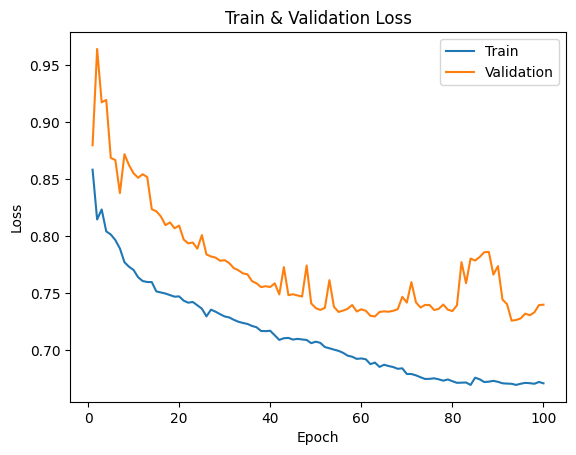

In [58]:
plot_loss()